In [9]:
import pandas as pd

df = pd.read_csv("india_weather_rainfall_data.csv")

print("Stations:", df["station_name"].nunique())

station_stats = (
    df.groupby("station_name")
      .agg(
          observations=("date_of_record","count"),
          missing_avg_temp=("avg_temp", lambda x: x.isna().sum()),
          missing_rainfall=("rainfall", lambda x: x.isna().sum()),
          missing_pressure=("air_pressure", lambda x: x.isna().sum()),
          missing_wind=("wind_speed", lambda x: x.isna().sum())
      )
      .sort_values("observations", ascending=False)
)

station_stats.head(20)

Stations: 406


,observations,missing_avg_temp,missing_rainfall,missing_pressure,missing_wind
station_name,,,,,
Thiruvananthapuram,7388,0,2010,1000,728
Srinagar,7388,0,2566,2664,2664
Akola,7276,0,3256,4298,4298
Madurai,6700,0,2340,2792,294
Agra,4794,0,2834,0,0
Siliguri,3906,0,350,922,922
Bangalore,3694,0,1086,1601,60
Calicut / Kondotti,3694,0,1154,1934,291
Bombay / Santacruz,3694,0,1458,366,304


In [10]:
df["date_of_record"] = pd.to_datetime(df["date_of_record"])

print(
    df["date_of_record"].min(),
    df["date_of_record"].max()
)

2015-01-01 00:00:00 2025-02-10 00:00:00


# EDA

In [11]:
stations = [
    "Agra",
    "New Delhi / Safdarjung",
    "Bangalore",
    "Thiruvananthapuram"
]

cols = [
    "avg_temp",
    "min_temp",
    "max_temp",
    "rainfall",
    "wind_speed",
    "air_pressure"
]

for st in stations:
    temp = df[df["station_name"] == st]

    print("\n", st)
    print("Rows:", len(temp))

    print(
        temp[cols]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )


 Agra
Rows: 4794
avg_temp         0.00
min_temp         0.00
max_temp         0.00
rainfall        59.12
wind_speed       0.00
air_pressure     0.00
dtype: float64

 New Delhi / Safdarjung
Rows: 3694
avg_temp         0.00
min_temp         0.79
max_temp         0.19
rainfall        52.68
wind_speed       4.41
air_pressure    15.51
dtype: float64

 Bangalore
Rows: 3694
avg_temp         0.00
min_temp         0.14
max_temp         0.03
rainfall        29.40
wind_speed       1.62
air_pressure    43.34
dtype: float64

 Thiruvananthapuram
Rows: 7388
avg_temp         0.00
min_temp         1.43
max_temp         0.19
rainfall        27.21
wind_speed       9.85
air_pressure    13.54
dtype: float64


In [12]:
agra = df[df["station_name"]=="Agra"].copy()

agra["date_of_record"] = pd.to_datetime(
    agra["date_of_record"]
)

agra = agra.sort_values("date_of_record")

print(
    agra["date_of_record"].min(),
    agra["date_of_record"].max()
)

print(
    "Unique dates:",
    agra["date_of_record"].nunique()
)

2018-07-21 00:00:00 2025-02-10 00:00:00
Unique dates: 2397


In [13]:
for st in [
    "Thiruvananthapuram",
    "Agra",
    "New Delhi / Safdarjung"
]:

    temp = df[df["station_name"] == st].copy()

    temp["date_of_record"] = pd.to_datetime(
        temp["date_of_record"]
    )

    print("\n", st)

    print(
        temp["date_of_record"].min(),
        temp["date_of_record"].max()
    )

    print(
        "Unique Dates:",
        temp["date_of_record"].nunique()
    )


 Thiruvananthapuram
2015-01-01 00:00:00 2025-02-10 00:00:00
Unique Dates: 3694

 Agra
2018-07-21 00:00:00 2025-02-10 00:00:00
Unique Dates: 2397

 New Delhi / Safdarjung
2015-01-01 00:00:00 2025-02-10 00:00:00
Unique Dates: 3694


In [14]:
station = "Thiruvananthapuram"

ts = (
    df[df["station_name"] == station]
    .copy()
)

ts["date_of_record"] = pd.to_datetime(ts["date_of_record"])

cols = [
    "avg_temp",
    "min_temp",
    "max_temp",
    "rainfall",
    "wind_speed",
    "air_pressure"
]

print(ts[cols].describe().T)

print("\nMissing %")
print(
    ts[cols]
    .isna()
    .mean()
    .mul(100)
    .round(2)
)

               count         mean        std    min       25%     50%     75%  \
avg_temp      7388.0    28.096075   1.324244   23.2    27.300    28.0    28.9   
min_temp      7282.0    24.531887   1.363106   18.9    23.700    24.5    25.3   
max_temp      7374.0    32.409493   1.468336   25.5    31.400    32.3    33.4   
rainfall      5378.0     7.598085  16.273657    0.0     0.000     1.0     7.1   
wind_speed    6660.0     7.050225   4.101221    0.2     3.675     6.6     9.6   
air_pressure  6388.0  1009.321775   2.388323  963.4  1008.300  1009.4  1010.5   

                 max  
avg_temp        32.8  
min_temp        31.0  
max_temp        39.8  
rainfall       211.1  
wind_speed      20.9  
air_pressure  1015.2  

Missing %
avg_temp         0.00
min_temp         1.43
max_temp         0.19
rainfall        27.21
wind_speed       9.85
air_pressure    13.54
dtype: float64


In [15]:
import pandas as pd

station = "Thiruvananthapuram"

ts = (
    df[df["station_name"] == station]
    .copy()
)

ts["date_of_record"] = pd.to_datetime(ts["date_of_record"])

ts = (
    ts.sort_values("date_of_record")
      .set_index("date_of_record")
)

print(ts.shape)

print(
    "\nDate Range:",
    ts.index.min(),
    "to",
    ts.index.max()
)

print(
    "\nDuplicate Dates:",
    ts.index.duplicated().sum()
)

print(
    "\nMissing Dates:",
    len(
        pd.date_range(
            ts.index.min(),
            ts.index.max(),
            freq="D"
        )
    ) - ts.index.nunique()
)

(7388, 14)

Date Range: 2015-01-01 00:00:00 to 2025-02-10 00:00:00

Duplicate Dates: 3694

Missing Dates: 0


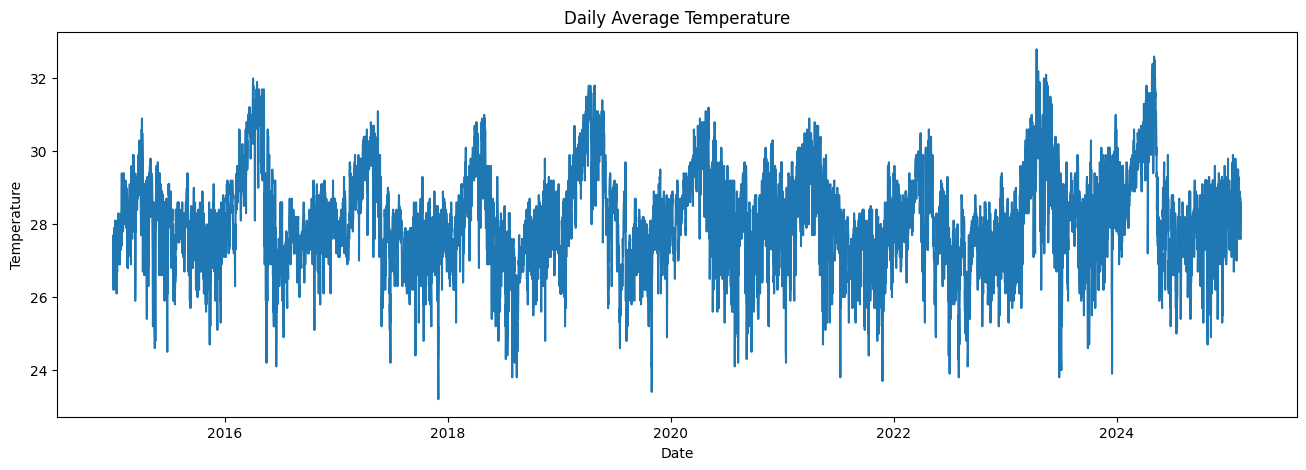

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,5))

plt.plot(ts.index, ts["avg_temp"])

plt.title("Daily Average Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")

plt.show()

In [17]:
annual = (
    ts["avg_temp"]
    .resample("Y")
    .mean()
)

annual

/tmp/ipykernel_736/189805120.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample("Y")


,avg_temp
date_of_record,
2015-12-31,27.849041
2016-12-31,28.362978
2017-12-31,27.990000
2018-12-31,27.791644
2019-12-31,28.294795
2020-12-31,28.275000
2021-12-31,27.819315
2022-12-31,27.668630
2023-12-31,28.436438


<Axes: xlabel='date_of_record'>

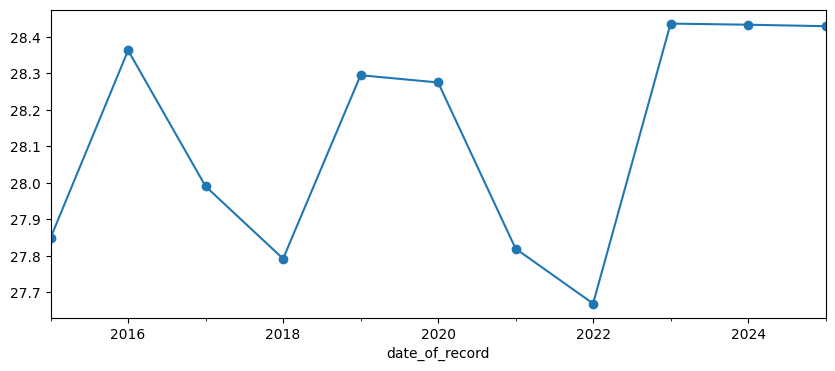

In [18]:
annual.plot(
    figsize=(10,4),
    marker="o"
)

In [19]:
ts.reset_index().groupby("date_of_record").size().value_counts()

,count
2,3694


In [20]:
(
    ts.reset_index()
      .groupby("date_of_record")
      .size()
      .sort_values(ascending=False)
      .head(10)
)

,0
date_of_record,
2025-02-10,2
2015-01-01,2
2015-01-02,2
2015-01-03,2
2015-01-04,2
2015-01-05,2
2015-01-06,2
2015-01-07,2
2015-01-08,2


In [21]:
thiru = df[df["station_name"]=="Thiruvananthapuram"]

print(thiru[["date_of_record","state","district"]].head(20))

       date_of_record state            district
896909     2015-01-01    KL  Thiruvananthapuram
896910     2015-01-02    KL  Thiruvananthapuram
896911     2015-01-03    KL  Thiruvananthapuram
896912     2015-01-04    KL  Thiruvananthapuram
896913     2015-01-05    KL  Thiruvananthapuram
896914     2015-01-06    KL  Thiruvananthapuram
896915     2015-01-07    KL  Thiruvananthapuram
896916     2015-01-08    KL  Thiruvananthapuram
896917     2015-01-09    KL  Thiruvananthapuram
896918     2015-01-10    KL  Thiruvananthapuram
896919     2015-01-11    KL  Thiruvananthapuram
896920     2015-01-12    KL  Thiruvananthapuram
896921     2015-01-13    KL  Thiruvananthapuram
896922     2015-01-14    KL  Thiruvananthapuram
896923     2015-01-15    KL  Thiruvananthapuram
896924     2015-01-16    KL  Thiruvananthapuram
896925     2015-01-17    KL  Thiruvananthapuram
896926     2015-01-18    KL  Thiruvananthapuram
896927     2015-01-19    KL  Thiruvananthapuram
896928     2015-01-20    KL  Thiruvanant

In [22]:
thiru[["state","district"]].drop_duplicates()

,state,district
896909,KL,Thiruvananthapuram


In [23]:
thiru = df[df["station_name"]=="Thiruvananthapuram"].copy()

dup_day = thiru[thiru["date_of_record"]=="2015-01-01"]

display(dup_day)

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
896909,2015-01-01,January,Winter,Thiruvananthapuram,KL,Thiruvananthapuram,26.6,NaN,31.4,NaN,NaN,60,8.4833,76.95,2.0
900603,2015-01-01,January,Winter,Thiruvananthapuram,KL,Thiruvananthapuram,27.7,NaN,31.7,NaN,NaN,4,8.4667,76.95,2.0


In [24]:
thiru[
    thiru["date_of_record"]
    .isin(["2015-01-01","2020-06-15","2024-01-01"])
].sort_values("date_of_record")

/tmp/ipykernel_736/2715969468.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  .isin(["2015-01-01","2020-06-15","2024-01-01"])


,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
896909,2015-01-01,January,Winter,Thiruvananthapuram,KL,Thiruvananthapuram,26.6,NaN,31.4,NaN,NaN,60,8.4833,76.95,2.0
900603,2015-01-01,January,Winter,Thiruvananthapuram,KL,Thiruvananthapuram,27.7,NaN,31.7,NaN,NaN,4,8.4667,76.95,2.0
898901,2020-06-15,June,Summer,Thiruvananthapuram,KL,Thiruvananthapuram,28.7,25.3,33.4,4.5,1007.9,60,8.4833,76.95,0.3
902595,2020-06-15,June,Summer,Thiruvananthapuram,KL,Thiruvananthapuram,30.1,26.0,33.0,10.2,1007.3,4,8.4667,76.95,0.8
900196,2024-01-01,January,Winter,Thiruvananthapuram,KL,Thiruvananthapuram,27.8,25.4,31.3,1.4,1011.7,60,8.4833,76.95,0.4
903890,2024-01-01,January,Winter,Thiruvananthapuram,KL,Thiruvananthapuram,29.1,27.0,31.0,5.3,1011.5,4,8.4667,76.95,0.4


In [25]:
import pandas as pd
import numpy as np

thiru = (
    df[df["station_name"] == "Thiruvananthapuram"]
    .copy()
)

thiru["date_of_record"] = pd.to_datetime(
    thiru["date_of_record"]
)

num_cols = [
    "avg_temp",
    "min_temp",
    "max_temp",
    "rainfall",
    "wind_speed",
    "air_pressure"
]

ts = (
    thiru
    .groupby("date_of_record")[num_cols]
    .mean()
    .sort_index()
)

print(ts.shape)

print(
    "\nDuplicate Dates:",
    ts.index.duplicated().sum()
)

print(
    "\nDate Range:",
    ts.index.min(),
    ts.index.max()
)

ts.head()

(3694, 6)

Duplicate Dates: 0

Date Range: 2015-01-01 00:00:00 2025-02-10 00:00:00


,avg_temp,min_temp,max_temp,rainfall,wind_speed,air_pressure
date_of_record,,,,,,
2015-01-01,27.15,NaN,31.55,2.0,NaN,NaN
2015-01-02,26.70,19.95,33.15,NaN,NaN,NaN
2015-01-03,26.85,21.15,33.15,NaN,NaN,NaN
2015-01-04,27.45,23.85,32.65,NaN,NaN,NaN
2015-01-05,27.50,23.05,32.05,NaN,NaN,NaN


In [26]:
(
    ts.isna()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

,0
rainfall,27.21
air_pressure,13.54
wind_speed,9.85
min_temp,1.43
max_temp,0.19
avg_temp,0.00


/tmp/ipykernel_736/3376686841.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts["avg_temp"].resample("M").mean().plot(ax=ax[1])
/tmp/ipykernel_736/3376686841.py:14: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  ts["avg_temp"].resample("Y").mean().plot(


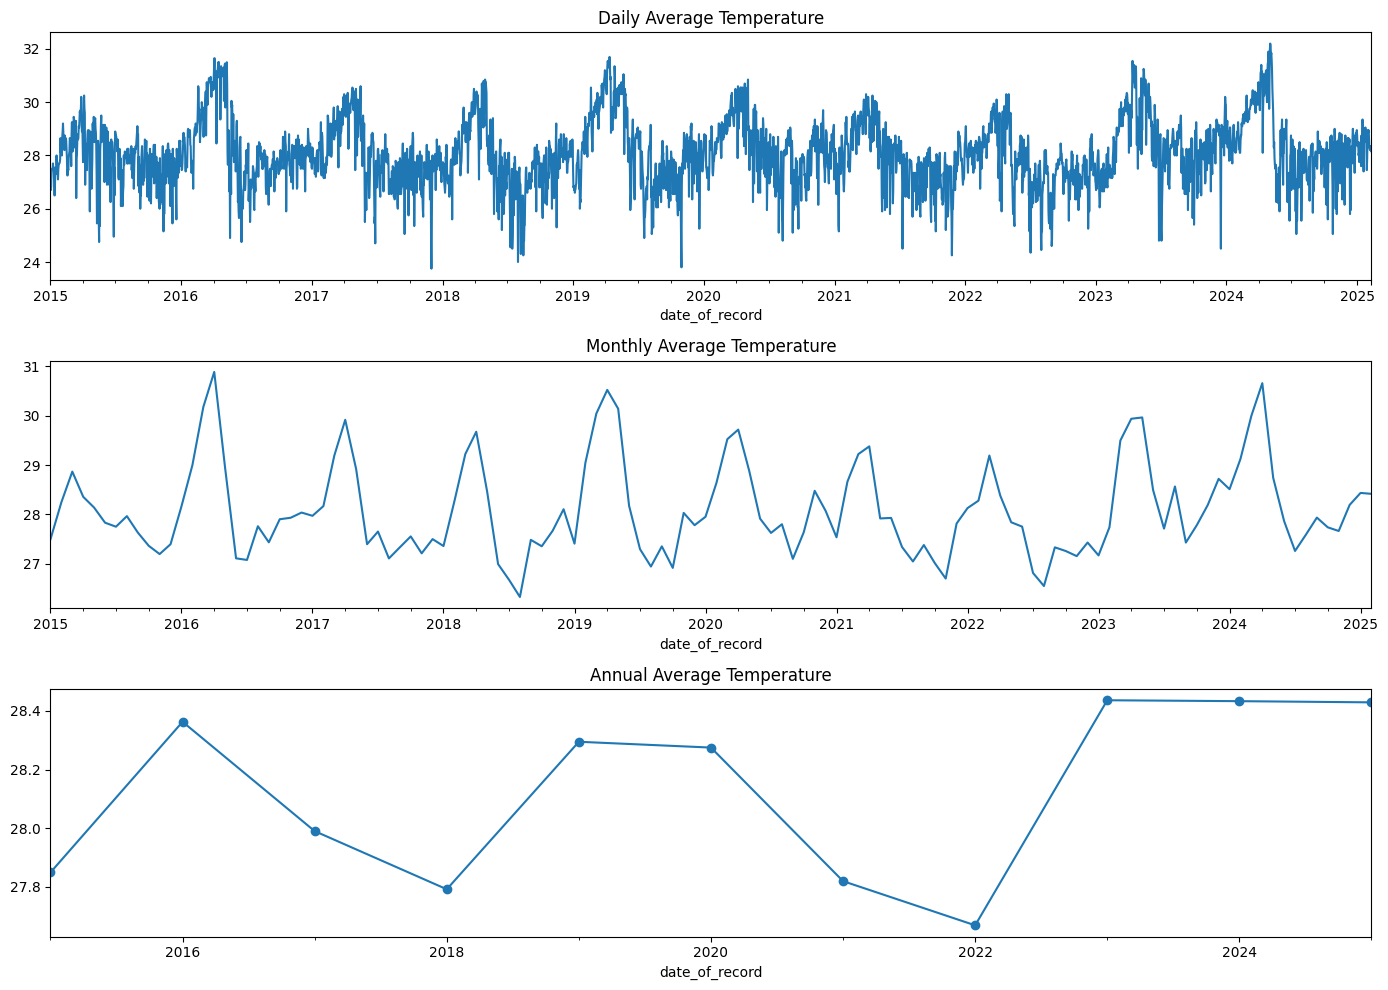

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(14, 10))

# Daily
ts["avg_temp"].plot(ax=ax[0])
ax[0].set_title("Daily Average Temperature")

# Monthly average
ts["avg_temp"].resample("M").mean().plot(ax=ax[1])
ax[1].set_title("Monthly Average Temperature")

# Annual average
ts["avg_temp"].resample("Y").mean().plot(
    ax=ax[2],
    marker="o"
)
ax[2].set_title("Annual Average Temperature")

plt.tight_layout()
plt.show()

In [28]:
thiru = df[df["station_name"]=="Thiruvananthapuram"]

(
    thiru[
        ["latitude","longitude","elevation"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

,latitude,longitude,elevation
0,8.4833,76.95,60
1,8.4667,76.95,4


In [29]:
thiru.groupby(
    ["latitude","longitude","elevation"]
).size()

,,,0
latitude,longitude,elevation,
8.4667,76.95,4,3694
8.4833,76.95,60,3694


In [30]:
pivot = thiru.pivot_table(
    index="date_of_record",
    values="avg_temp",
    columns=["latitude","longitude","elevation"]
)

pivot.corr()

,,latitude,8.4667,8.4833
,,longitude,76.95,76.95
,,elevation,4,60
latitude,longitude,elevation,,
8.4667,76.95,4,1.000000,0.898554
8.4833,76.95,60,0.898554,1.000000


In [31]:
thiru = df[df["station_name"]=="Thiruvananthapuram"].copy()

station_summary = (
    thiru.groupby(
        ["latitude","longitude","elevation"]
    )[[
        "avg_temp",
        "min_temp",
        "max_temp",
        "rainfall",
        "wind_speed",
        "air_pressure"
    ]]
    .apply(lambda x: x.isna().mean()*100)
)

station_summary

,,,avg_temp,min_temp,max_temp,rainfall,wind_speed,air_pressure
latitude,longitude,elevation,,,,,,
8.4667,76.95,4,0.0,1.434759,0.189496,27.20628,9.853817,13.535463
8.4833,76.95,60,0.0,1.434759,0.189496,27.20628,9.853817,13.535463


In [32]:
pivot = thiru.pivot_table(
    index="date_of_record",
    values="avg_temp",
    columns=["latitude","longitude","elevation"]
)

diff = pivot.iloc[:,0] - pivot.iloc[:,1]

print(diff.describe())

count    3694.000000
mean        0.734759
std         0.573264
min        -1.700000
25%         0.400000
50%         0.700000
75%         1.100000
max         3.300000
dtype: float64


In [33]:
station = (
    (df["station_name"] == "Thiruvananthapuram") &
    (df["latitude"] == 8.4667) &
    (df["elevation"] == 4)
)

ts = df.loc[station].copy()

ts["date_of_record"] = pd.to_datetime(
    ts["date_of_record"]
)

ts = (
    ts.sort_values("date_of_record")
      .set_index("date_of_record")
)

print(ts.shape)
print(ts.index.min(), ts.index.max())

(3694, 14)
2015-01-01 00:00:00 2025-02-10 00:00:00


In [34]:
missing = (
    ts.isna()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print(missing)

rainfall        27.21
air_pressure    13.54
wind_speed       9.85
min_temp         1.43
max_temp         0.19
month            0.00
avg_temp         0.00
district         0.00
state            0.00
station_name     0.00
season           0.00
elevation        0.00
latitude         0.00
longitude        0.00
dtype: float64


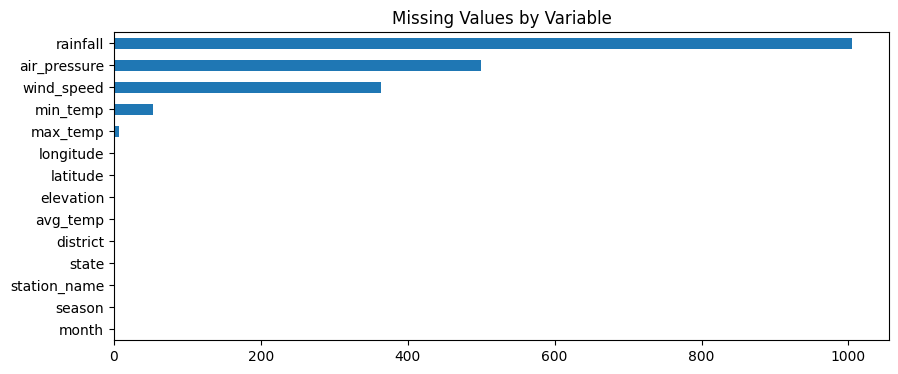

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

ts.isna().sum().sort_values().plot(
    kind="barh"
)

plt.title("Missing Values by Variable")
plt.show()

In [36]:
missing_by_year = (
    ts.isna()
      .groupby(ts.index.year)
      .mean()
      .mul(100)
)

missing_by_year

,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
date_of_record,,,,,,,,,,,,,,
2015,0.0,0.0,0.0,0.0,0.0,0.0,14.520548,1.369863,91.232877,95.068493,0.0,0.0,0.0,35.890411
2016,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.273224,5.737705,31.693989,0.0,0.0,0.0,43.715847
2017,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.273973,1.917808,7.123288,0.0,0.0,0.0,35.068493
2018,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.821918,3.013699,0.0,0.0,0.0,37.260274
2019,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,39.178082
2020,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,34.972678
2021,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,29.315068
2022,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,19.452055
2023,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


# Seasonality Exploration

date_of_record
1     28.25
2     28.84
3     29.80
4     30.10
5     29.21
6     28.12
7     27.61
8     27.57
9     27.72
10    27.89
11    28.13
12    28.37
Name: avg_temp, dtype: float64


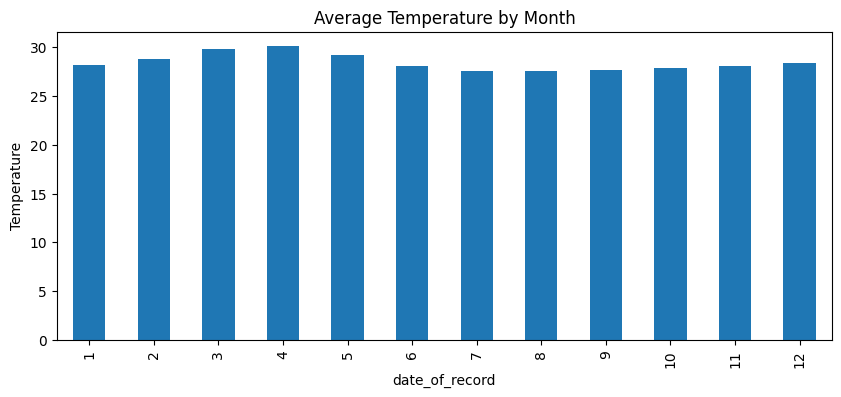

In [37]:
import matplotlib.pyplot as plt

month_avg = (
    ts.groupby(ts.index.month)["avg_temp"]
      .mean()
)

print(month_avg.round(2))

month_avg.plot(
    kind="bar",
    figsize=(10,4)
)

plt.title("Average Temperature by Month")
plt.ylabel("Temperature")
plt.show()

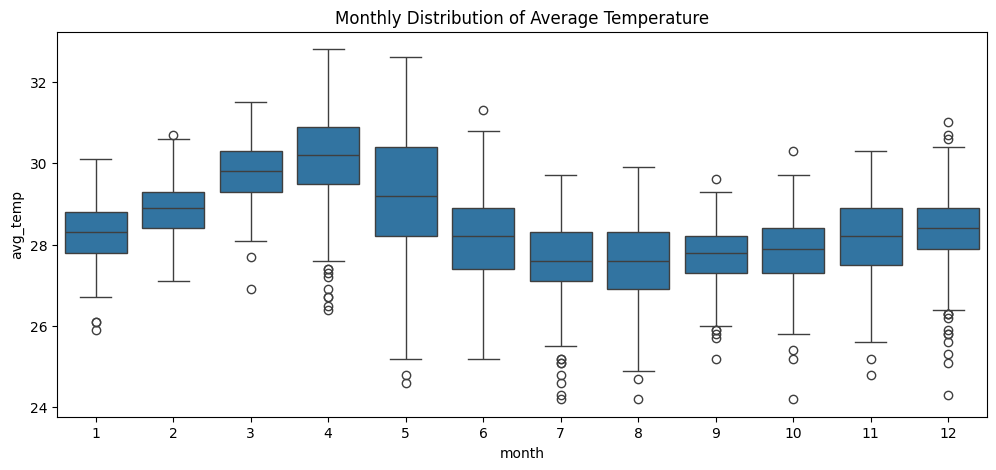

In [38]:
import seaborn as sns

temp = ts.copy()

temp["month"] = temp.index.month

plt.figure(figsize=(12,5))

sns.boxplot(
    data=temp,
    x="month",
    y="avg_temp"
)

plt.title("Monthly Distribution of Average Temperature")
plt.show()

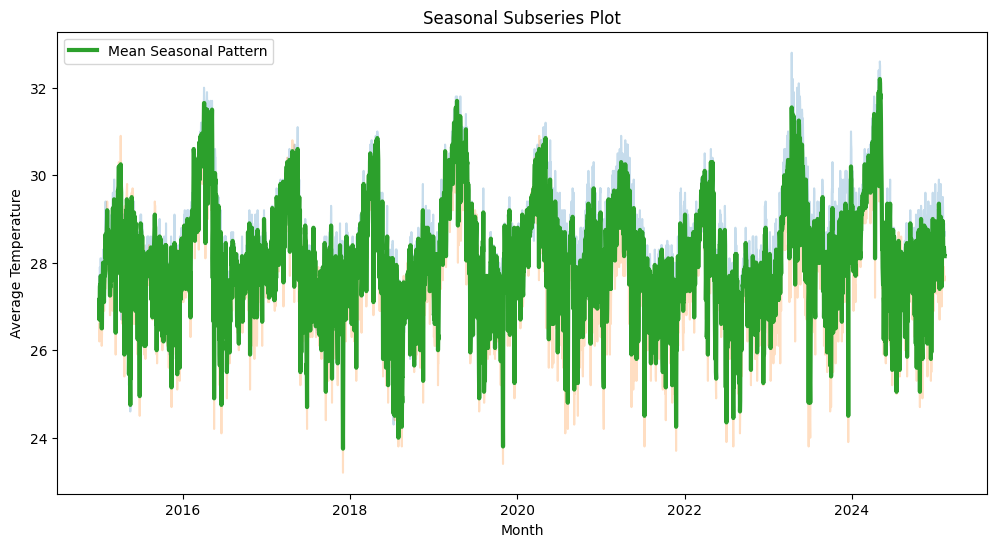

In [39]:
plt.figure(figsize=(12,6))

for col in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[col],
        alpha=0.25
    )

plt.plot(
    pivot.index,
    pivot.mean(axis=1),
    linewidth=3,
    label="Mean Seasonal Pattern"
)

plt.legend()

plt.title("Seasonal Subseries Plot")
plt.xlabel("Month")
plt.ylabel("Average Temperature")

plt.show()

/tmp/ipykernel_736/494374490.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


(122,)


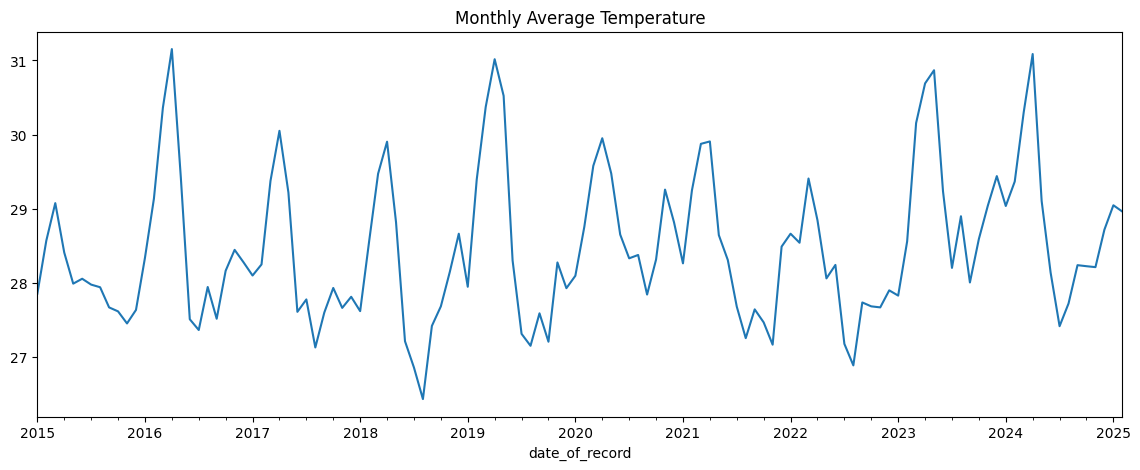

In [40]:
monthly = (
    ts["avg_temp"]
    .resample("M")
    .mean()
)

print(monthly.shape)

monthly.plot(
    figsize=(14,5)
)
plt.title("Monthly Average Temperature")
plt.show()

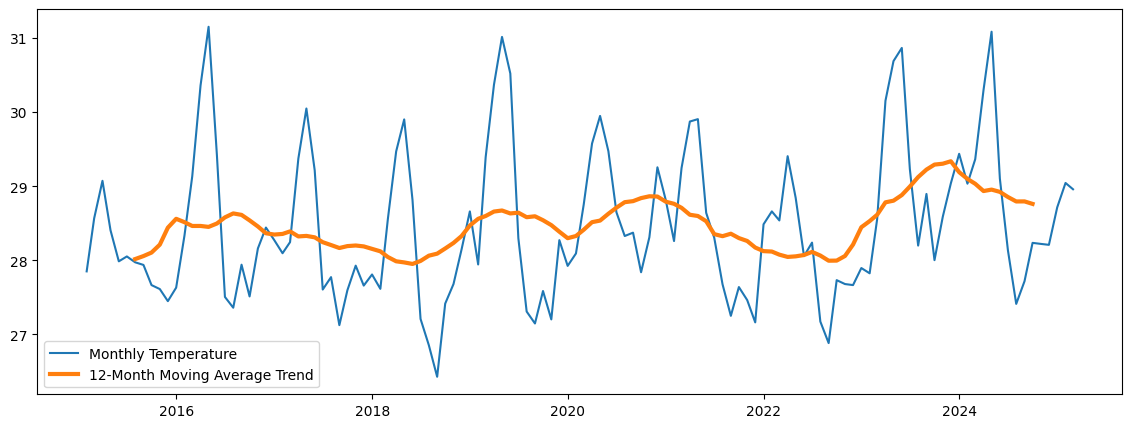

In [41]:
trend_ma = (
    monthly
    .rolling(
        window=12,
        center=True
    )
    .mean()
)

plt.figure(figsize=(14,5))

plt.plot(
    monthly,
    label="Monthly Temperature"
)

plt.plot(
    trend_ma,
    linewidth=3,
    label="12-Month Moving Average Trend"
)

plt.legend()
plt.show()

# Trend Estimation

In [42]:
import statsmodels.api as sm
import numpy as np

y = monthly.values

t = np.arange(len(y))

X = sm.add_constant(t)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     2.981
Date:                Tue, 18 Aug 2026   Prob (F-statistic):             0.0868
Time:                        20:51:59   Log-Likelihood:                -170.33
No. Observations:                 122   AIC:                             344.7
Df Residuals:                     120   BIC:                             350.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.2046      0.177    159.015      0.0

# STL Decomposition

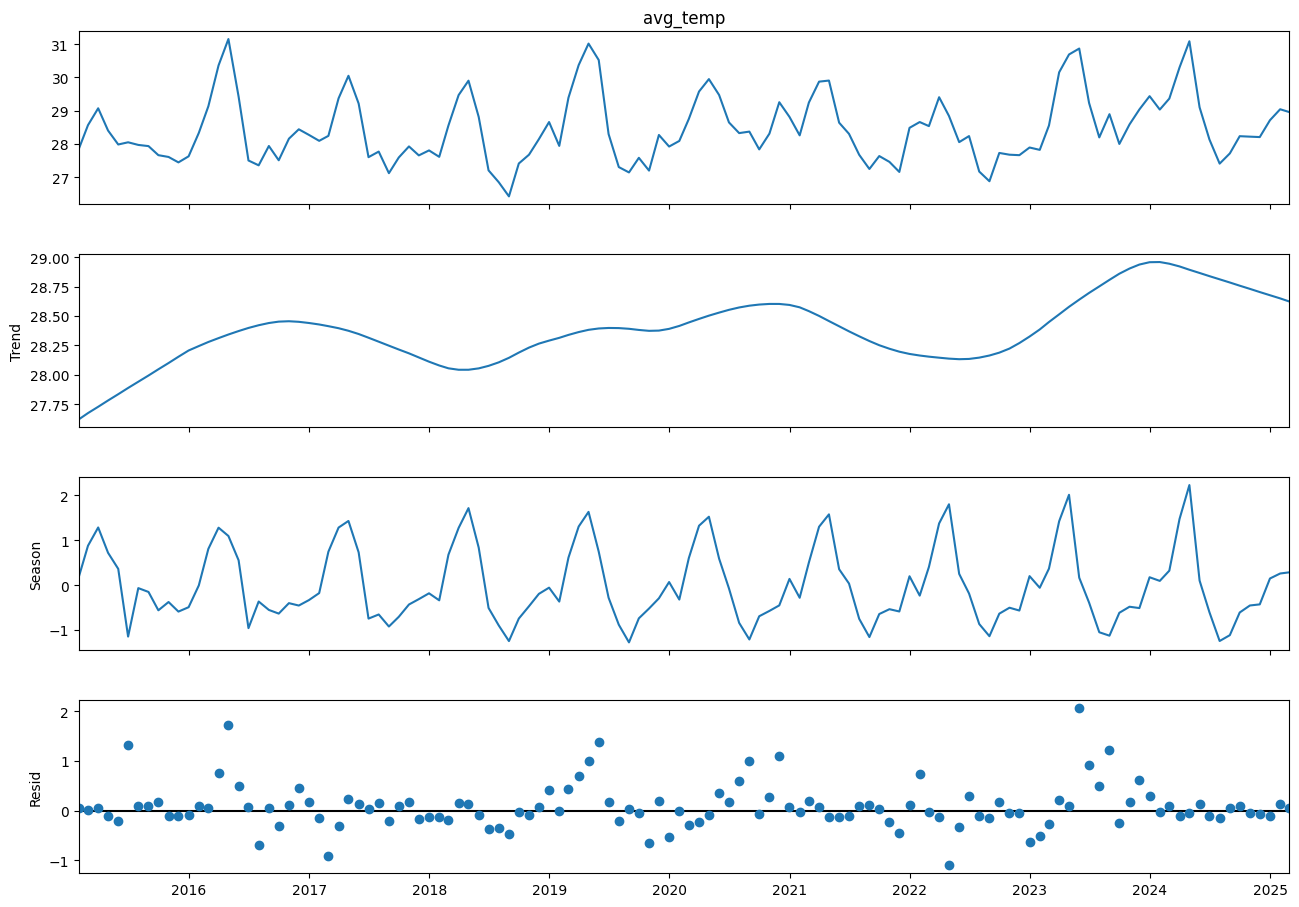

In [43]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

stl = STL(
    monthly,
    period=12,
    robust=True
)

res = stl.fit()

fig = res.plot()
fig.set_size_inches(14,10)

plt.show()

In [44]:
trend = res.trend
seasonal = res.seasonal
remainder = res.resid

print("Trend Variance:")
print(trend.var())

print("\nSeasonal Variance:")
print(seasonal.var())

print("\nResidual Variance:")
print(remainder.var())

Trend Variance:
0.07840158794646243

Seasonal Variance:
0.6822765894044117

Residual Variance:
0.21063943430711038


# Seasonal Component Estimation

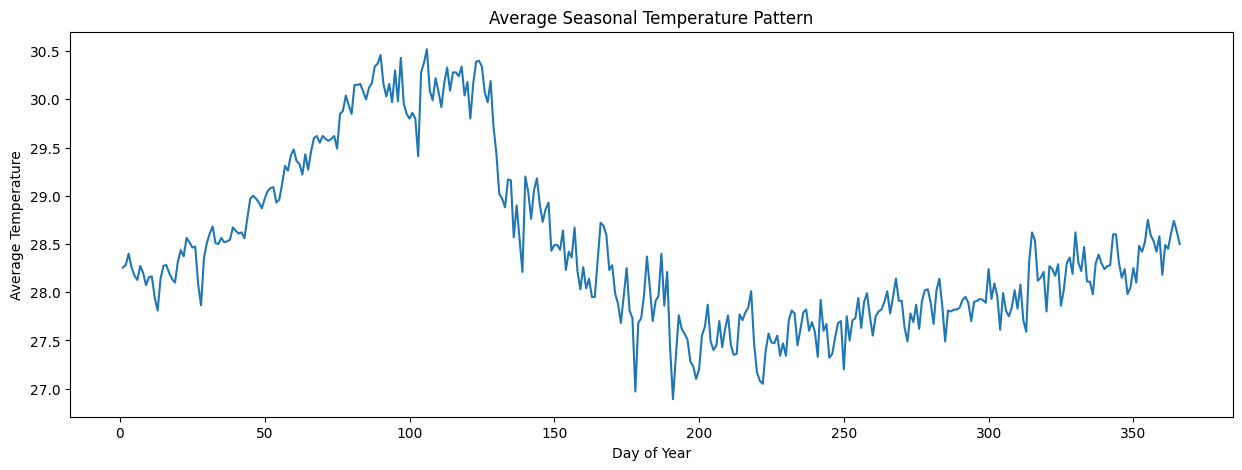

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

daily = ts.copy()

daily["doy"] = daily.index.dayofyear

seasonal_profile = (
    daily.groupby("doy")["avg_temp"]
    .mean()
)

plt.figure(figsize=(15,5))

plt.plot(
    seasonal_profile.index,
    seasonal_profile.values
)

plt.title("Average Seasonal Temperature Pattern")
plt.xlabel("Day of Year")
plt.ylabel("Average Temperature")

plt.show()

In [46]:
from statsmodels.tsa.seasonal import STL

stl_daily = STL(
    daily["avg_temp"],
    period=365,
    robust=True
)

res_daily = stl_daily.fit()

trend_var = res_daily.trend.var()
season_var = res_daily.seasonal.var()
resid_var = res_daily.resid.var()

total_var = (
    trend_var +
    season_var +
    resid_var
)

print("Trend %:",
      round(100*trend_var/total_var,2))

print("Seasonal %:",
      round(100*season_var/total_var,2))

print("Residual %:",
      round(100*resid_var/total_var,2))

Trend %: 4.53
Seasonal %: 56.38
Residual %: 39.09


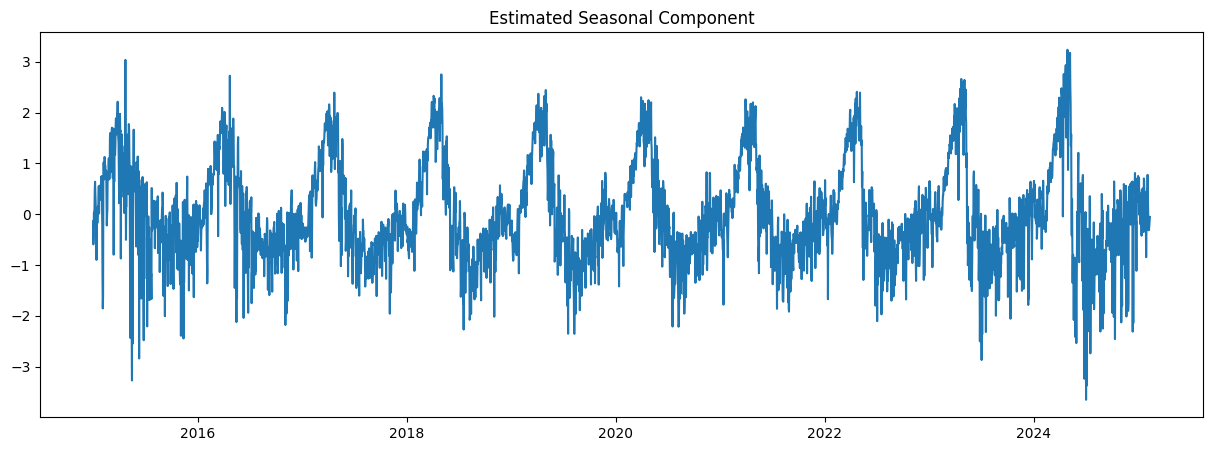

In [47]:
plt.figure(figsize=(15,5))

plt.plot(
    res_daily.seasonal
)

plt.title(
    "Estimated Seasonal Component"
)

plt.show()

# Detrending and Frequency Domain Analysis

In [48]:
detrended = daily["avg_temp"] - res_daily.trend

deseasonalized = daily["avg_temp"] - res_daily.seasonal

remainder = res_daily.resid

print("Original Variance      :", daily["avg_temp"].var())
print("Detrended Variance     :", detrended.var())
print("Deseasonalized Variance:", deseasonalized.var())
print("Residual Variance      :", remainder.var())

Original Variance      : 1.6008790478657582
Detrended Variance     : 1.5024274701178884
Deseasonalized Variance: 0.784711035126272
Residual Variance      : 0.6593480970922514


In [49]:
from statsmodels.tsa.stattools import adfuller

series_dict = {
    "Original": daily["avg_temp"],
    "Detrended": detrended,
    "Deseasonalized": deseasonalized,
    "Residual": remainder
}

for name, series in series_dict.items():
    result = adfuller(series.dropna())

    print("\n", "="*40)
    print(name)
    print("="*40)
    print("ADF Statistic :", round(result[0],4))
    print("p-value       :", round(result[1],6))


Original
ADF Statistic : -5.2162
p-value       : 8e-06

Detrended
ADF Statistic : -5.4555
p-value       : 3e-06

Deseasonalized
ADF Statistic : -5.3774
p-value       : 4e-06

Residual
ADF Statistic : -11.7145
p-value       : 0.0


In [50]:
from scipy.signal import periodogram
import numpy as np

freqs, power = periodogram(
    daily["avg_temp"],
    detrend="linear"
)

idx = np.argsort(power)[-10:][::-1]

top_periods = pd.DataFrame({
    "Frequency": freqs[idx],
    "Period_Days": 1/freqs[idx],
    "Power": power[idx]
})

print(top_periods.round(4))

   Frequency  Period_Days      Power
0     0.0027     369.4000  1827.2728
1     0.0054     184.7000   534.6289
2     0.0008    1231.3333   184.0228
3     0.0011     923.5000   126.0714
4     0.0019     527.7143   123.1324
5     0.0081     123.1333    96.7292
6     0.0038     263.8571    90.7750
7     0.0051     194.4211    64.3366
8     0.0030     335.8182    58.9794
9     0.0005    1847.0000    51.1451


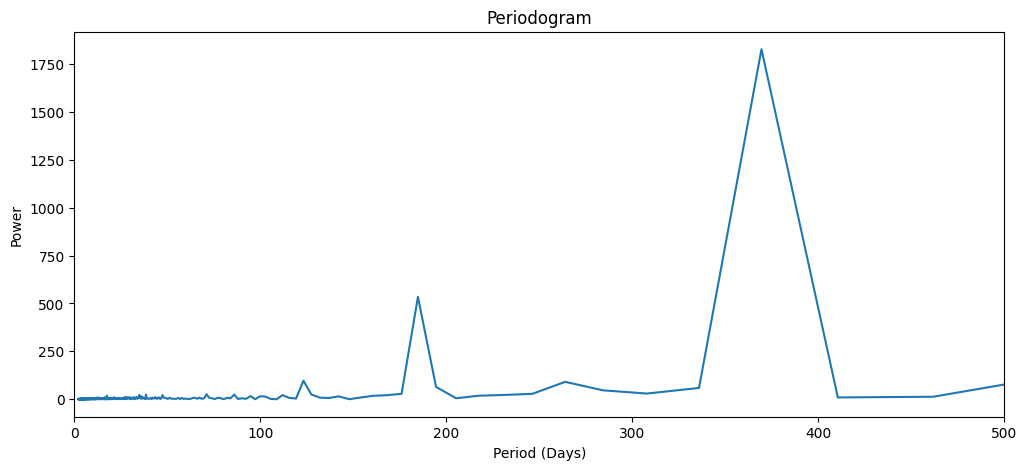

In [51]:
from scipy.signal import periodogram
import matplotlib.pyplot as plt

freqs, power = periodogram(
    daily["avg_temp"],
    detrend="linear"
)

plt.figure(figsize=(12,5))
plt.plot(
    1/freqs[1:],
    power[1:]
)

plt.xlim(0,500)

plt.xlabel("Period (Days)")
plt.ylabel("Power")
plt.title("Periodogram")

plt.show()

In [52]:
from scipy.signal import welch
import pandas as pd
import numpy as np

freqs_w, psd = welch(
    daily["avg_temp"].values,
    fs=1,
    nperseg=1024
)

spectral_table = pd.DataFrame({
    "Frequency": freqs_w,
    "PSD": psd
})

spectral_table = spectral_table[
    spectral_table["Frequency"] > 0
]

spectral_table["Period_Days"] = (
    1 / spectral_table["Frequency"]
)

spectral_table = (
    spectral_table
    .sort_values("PSD", ascending=False)
    .head(10)
)

print(spectral_table.round(4))

    Frequency       PSD  Period_Days
3      0.0029  398.7305     341.3333
2      0.0020  196.8238     512.0000
4      0.0039  106.8892     256.0000
5      0.0049  106.0770     204.8000
6      0.0059  105.3376     170.6667
1      0.0010   73.5442    1024.0000
8      0.0078   20.7077     128.0000
9      0.0088   20.6840     113.7778
7      0.0068   11.1936     146.2857
14     0.0137   10.7491      73.1429


# Forecasting Pipeline

The exploratory analysis confirmed strong annual seasonality and highlighted the need for seasonal forecasting models.

To evaluate forecasting performance fairly, the data is split chronologically. The first nine years are used for model fitting, while the final year is reserved as an unseen test set. This prevents information leakage and mimics a real forecasting scenario.

In [53]:
# =====================================================
# Chronological Train-Test Split
# =====================================================

forecast_horizon = 365

train = daily.iloc[:-forecast_horizon].copy()
test = daily.iloc[-forecast_horizon:].copy()

print(f"Training observations : {len(train)}")
print(f"Testing observations  : {len(test)}")

print("\nTraining Period")
print(train.index.min().date(), "to", train.index.max().date())

print("\nTesting Period")
print(test.index.min().date(), "to", test.index.max().date())

Training observations : 3329
Testing observations  : 365

Training Period
2015-01-01 to 2024-02-11

Testing Period
2024-02-12 to 2025-02-10


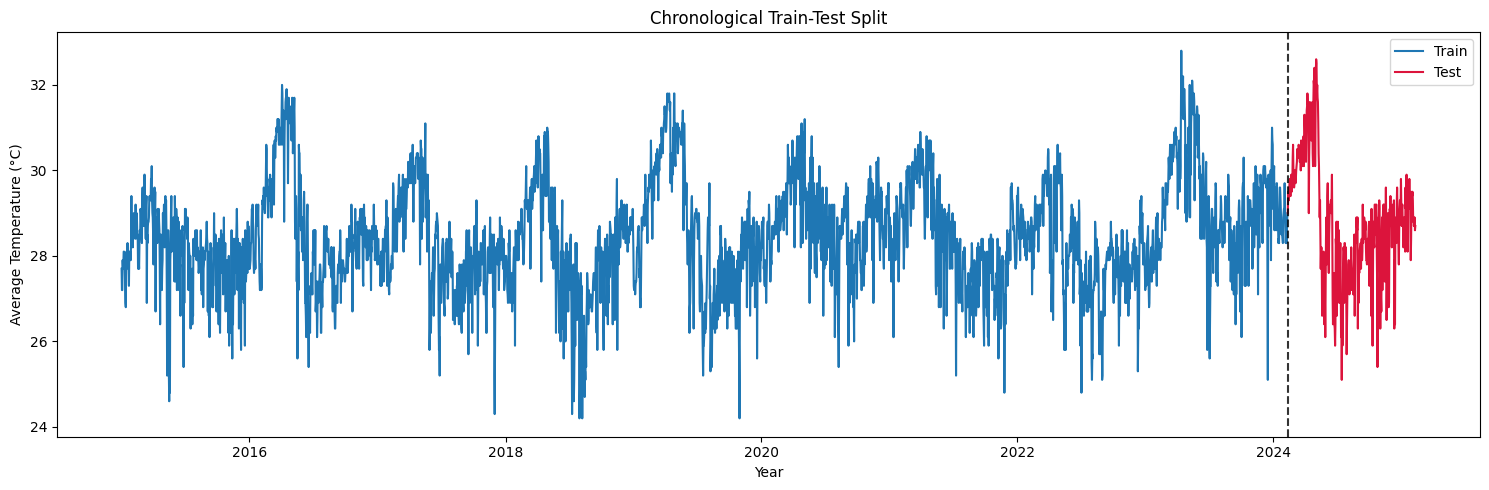

In [54]:
# =====================================================
# Visualize Train-Test Split
# =====================================================

plt.figure(figsize=(15,5))

plt.plot(train.index, train["avg_temp"], label="Train")
plt.plot(test.index, test["avg_temp"], label="Test", color="crimson")

plt.axvline(test.index[0], color="black", linestyle="--", alpha=0.8)

plt.title("Chronological Train-Test Split")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")

plt.legend()

plt.tight_layout()
plt.show()

### Train-Test Split conclusion

The time series was divided chronologically to preserve its temporal structure and prevent information leakage. The first 3329 daily observations (January 2015–February 2024) were used for model training, while the final 365 observations (February 2024–February 2025) were reserved as an unseen test set. This one-year hold-out period enables a fair comparison of all forecasting models under identical conditions.

In [55]:
# =====================================================
# Forecast Evaluation Metrics
# =====================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

def smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred))
    )


def mase(train, test, pred, seasonal_period=365):
    naive_error = np.mean(
        np.abs(
            train[seasonal_period:] -
            train[:-seasonal_period]
        )
    )

    return np.mean(np.abs(test - pred)) / naive_error


def evaluate_forecast(train, test, pred):

    return {
        "MAE": mean_absolute_error(test, pred),
        "RMSE": np.sqrt(mean_squared_error(test, pred)),
        "sMAPE": smape(test, pred),
        "MASE": mase(train.values,
                     test.values,
                     pred.values if hasattr(pred, "values") else pred)
    }

##Seasonal Naive

This is arguably the most important model in the notebook because every sophisticated model should outperform it.

Since your EDA clearly established a strong annual seasonality, the appropriate baseline is Seasonal Naïve with a seasonal period of 365 days.

The forecast is simply:

y_t = y_
t−365
	​


In other words, each day's forecast is the temperature observed on the same calendar day one year earlier.

In [56]:
# =====================================================
# Seasonal Naïve Forecast
# =====================================================

season_length = 365

seasonal_naive_forecast = (
    train["avg_temp"]
    .iloc[-season_length:]
    .reset_index(drop=True)
)

seasonal_naive_forecast.index = test.index

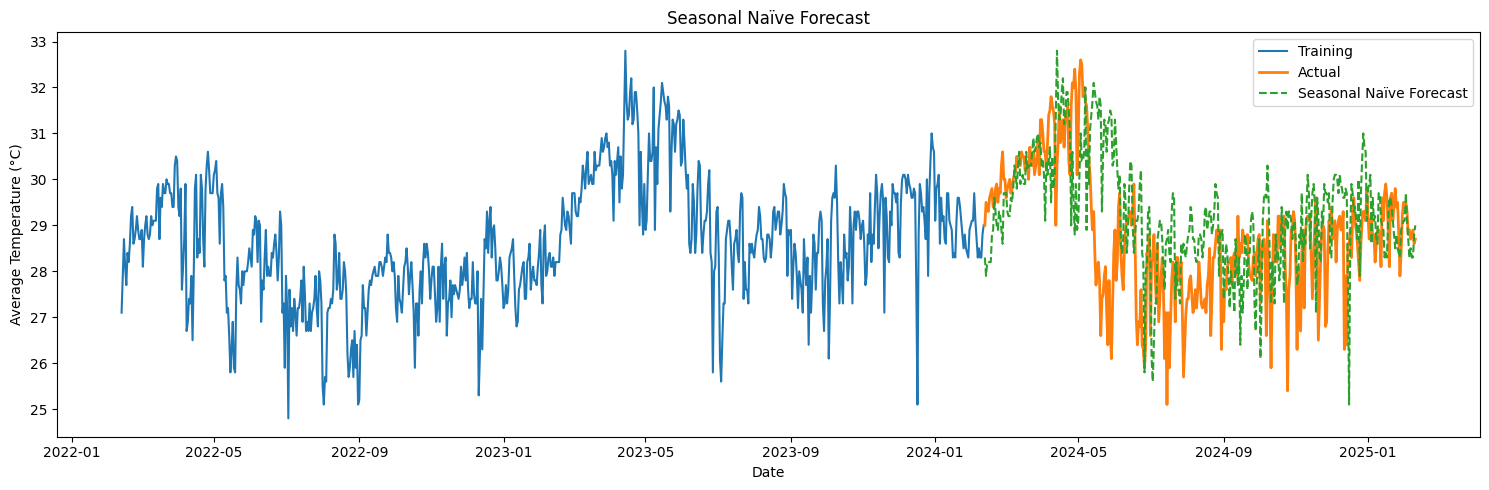

In [57]:
# =====================================================
# Seasonal Naïve Forecast
# =====================================================

plt.figure(figsize=(15,5))

plt.plot(train.index[-730:], train["avg_temp"][-730:], label="Training")
plt.plot(test.index, test["avg_temp"], label="Actual", linewidth=2)
plt.plot(
    test.index,
    seasonal_naive_forecast,
    "--",
    label="Seasonal Naïve Forecast",
)

plt.title("Seasonal Naïve Forecast")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")
plt.legend()

plt.tight_layout()
plt.show()

In [58]:
# =====================================================
# Seasonal Naïve Performance
# =====================================================

seasonal_naive_results = evaluate_forecast(
    train["avg_temp"],
    test["avg_temp"],
    seasonal_naive_forecast
)

pd.DataFrame(
    seasonal_naive_results,
    index=["Seasonal Naïve"]
)

,MAE,RMSE,sMAPE,MASE
Seasonal Naïve,1.143288,1.496727,3.958244,1.07014


In [59]:
# =====================================================
# Initialize Model Comparison Table
# =====================================================

results = pd.DataFrame(
    columns=["MAE", "RMSE", "sMAPE", "MASE"]
)

results

,MAE,RMSE,sMAPE,MASE


In [60]:
# =====================================================
# Model Comparison Table
# =====================================================
results.loc["Seasonal Naïve"] = pd.Series(seasonal_naive_results)

results.round(3)

results

,MAE,RMSE,sMAPE,MASE
Seasonal Naïve,1.143288,1.496727,3.958244,1.07014


## Seasonal Moving Average

The Seasonal Moving Average model provides a slightly more flexible baseline by smoothing historical seasonal observations before generating forecasts. Unlike the Seasonal Naïve approach, which directly repeats last year's values, this model reduces short-term fluctuations while retaining the dominant annual seasonal pattern. It serves as an intermediate benchmark between simple seasonal repetition and more sophisticated statistical models.

In [61]:
# =====================================================
# Seasonal Moving Average Forecast
# =====================================================

season_length = 365

history = train["avg_temp"].values

seasonal_ma_forecast = []

for i in range(season_length):

    seasonal_values = history[i::season_length]

    seasonal_ma_forecast.append(np.mean(seasonal_values))

seasonal_ma_forecast = pd.Series(
    seasonal_ma_forecast,
    index=test.index
)

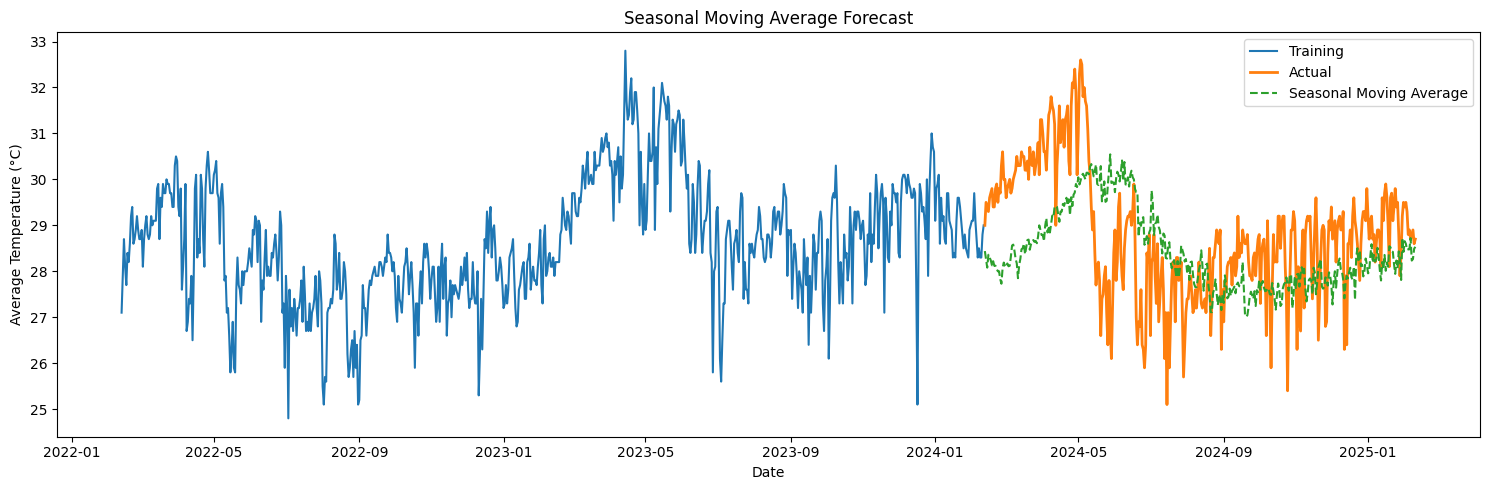

In [62]:
# =====================================================
# Seasonal Moving Average Forecast
# =====================================================

plt.figure(figsize=(15,5))

plt.plot(train.index[-730:], train["avg_temp"][-730:], label="Training")
plt.plot(test.index, test["avg_temp"], label="Actual", linewidth=2)
plt.plot(test.index,
         seasonal_ma_forecast,
         "--",
         label="Seasonal Moving Average")

plt.title("Seasonal Moving Average Forecast")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")
plt.legend()

plt.tight_layout()
plt.show()

In [63]:
# =====================================================
# Seasonal Moving Average Performance
# =====================================================

seasonal_ma_results = evaluate_forecast(
    train["avg_temp"],
    test["avg_temp"],
    seasonal_ma_forecast
)

results.loc["Seasonal Moving Average"] = pd.Series(seasonal_ma_results)

results.round(3)
results.sort_values("MASE")

,MAE,RMSE,sMAPE,MASE
Seasonal Naïve,1.143288,1.496727,3.958244,1.070140
Seasonal Moving Average,1.220478,1.445128,4.242447,1.142391


**Observation**

The Seasonal Moving Average did not outperform the Seasonal Naïve benchmark. Although averaging historical seasonal observations slightly reduced RMSE, it produced larger average forecast errors (MAE, sMAPE, and MASE). This suggests that repeating the previous year's temperatures better preserves year-specific seasonal patterns than smoothing across multiple years.

## Harmonic (Fourier) Regression

Harmonic regression models seasonality using sine and cosine basis functions. The seasonal cycle is represented as a linear combination of Fourier terms, allowing smooth periodic patterns to be captured without relying on lagged observations.

The harmonic order ($K$) determines the complexity of the seasonal component. Rather than choosing $K$ arbitrarily, it is selected using a validation set while keeping the final test set completely unseen. After selecting the optimal harmonic order, the model is refitted on the full training data and evaluated once on the test set.

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

In [65]:
# =====================================================
# Training / Validation Split (for model selection)
# =====================================================

validation_horizon = 365

train_sub = train.iloc[:-validation_horizon].copy()
val = train.iloc[-validation_horizon:].copy()

print(f"Training subset : {len(train_sub)}")
print(f"Validation set  : {len(val)}")

Training subset : 2964
Validation set  : 365


In [68]:
# =====================================================
# Fourier Feature Generator
# =====================================================

def create_fourier_features(index, period, K, start=0):
    """
    Generate Fourier features for a given datetime index.
    """

    n = len(index)
    t = np.arange(start, start + n)

    X = pd.DataFrame(index=index)

    for k in range(1, K + 1):

        X[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        X[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)

    return X

## Fourier Order Selection

The number of Fourier harmonics controls the flexibility of the seasonal component. Too few harmonics may underfit the annual cycle, whereas too many may overfit the training data.

To select an appropriate harmonic order, models with increasing values of \(K\) are evaluated on the validation set. The order yielding the lowest validation MASE is selected and subsequently refitted using the complete training data.

In [69]:
# =====================================================
# Fourier Order Selection
# =====================================================

from sklearn.linear_model import LinearRegression

fourier_validation = []

for K in range(1, 9):   # Try K = 1 to 8

    # Fourier features
    X_train_sub = create_fourier_features(
        index=train_sub.index,
        period=365,
        K=K,
        start=0
    )

    X_val = create_fourier_features(
        index=val.index,
        period=365,
        K=K,
        start=len(train_sub)
    )

    # Fit
    model = LinearRegression()

    model.fit(
        X_train_sub,
        train_sub["avg_temp"]
    )

    # Forecast
    pred = model.predict(X_val)

    # Evaluate
    metrics = evaluate_forecast(
        train_sub["avg_temp"],
        val["avg_temp"],
        pred
    )

    fourier_validation.append({
        "K": K,
        **metrics
    })

fourier_validation = (
    pd.DataFrame(fourier_validation)
    .sort_values("MASE")
    .reset_index(drop=True)
)

fourier_validation

,K,MAE,RMSE,sMAPE,MASE
0,4,1.084724,1.322634,3.748342,1.069499
1,3,1.085976,1.317648,3.751878,1.070733
2,5,1.097091,1.333591,3.791947,1.081692
3,7,1.099990,1.335490,3.801717,1.084550
4,6,1.100527,1.335230,3.803694,1.085080
5,8,1.101100,1.342012,3.806035,1.085645
6,2,1.105200,1.334456,3.819246,1.089687
7,1,1.132523,1.372818,3.906283,1.116627


In [70]:
best_k = int(fourier_validation.iloc[0]["K"])

print(f"Selected Fourier Order (K): {best_k}")

Selected Fourier Order (K): 4


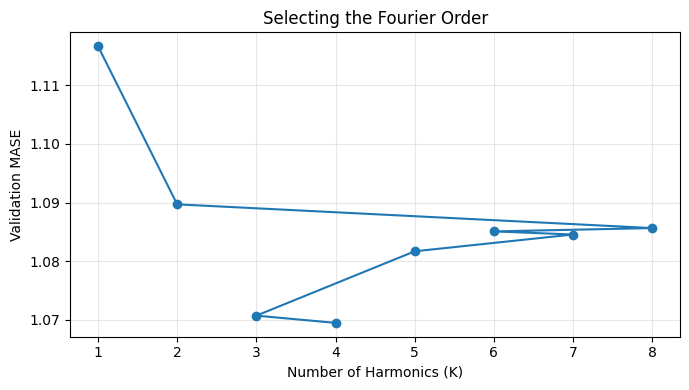

In [71]:
plt.figure(figsize=(7,4))

plt.plot(
    fourier_validation["K"],
    fourier_validation["MASE"],
    marker="o"
)

plt.xlabel("Number of Harmonics (K)")
plt.ylabel("Validation MASE")
plt.title("Selecting the Fourier Order")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
# =====================================================
# Final Harmonic Regression
# =====================================================

X_train = create_fourier_features(
    index=train.index,
    period=365,
    K=best_k,
    start=0
)

X_test = create_fourier_features(
    index=test.index,
    period=365,
    K=best_k,
    start=len(train)
)

fourier_model = LinearRegression()

fourier_model.fit(
    X_train,
    train["avg_temp"]
)

fourier_forecast = pd.Series(
    fourier_model.predict(X_test),
    index=test.index
)

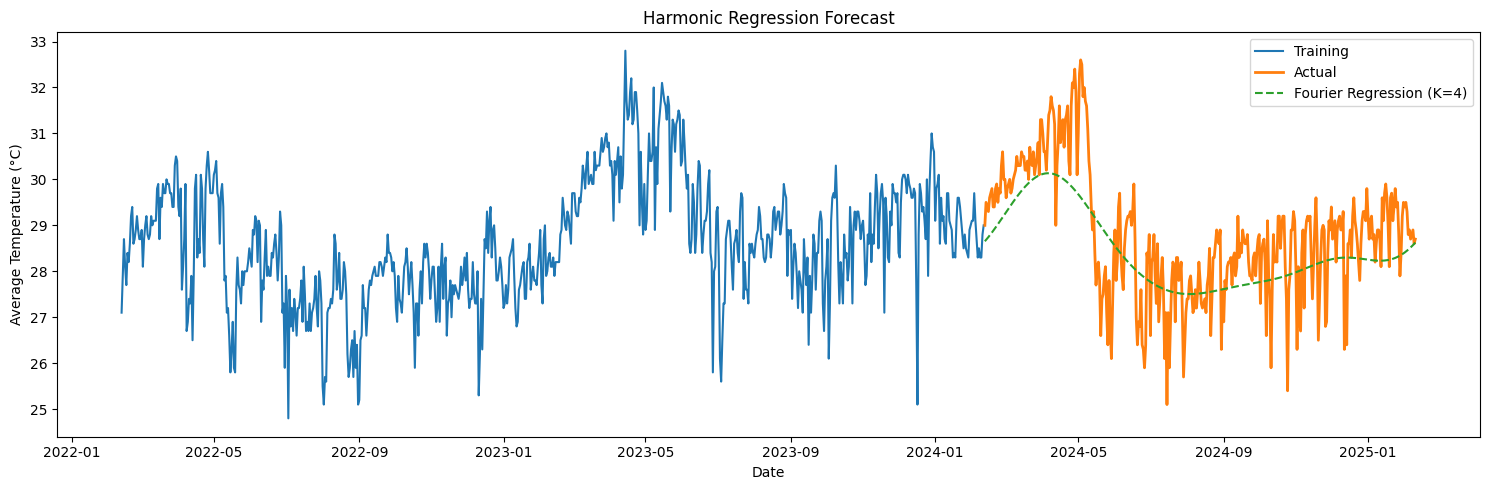

In [73]:
# =====================================================
# Harmonic Regression Forecast
# =====================================================

plt.figure(figsize=(15,5))

plt.plot(train.index[-730:], train["avg_temp"][-730:], label="Training")
plt.plot(test.index, test["avg_temp"], label="Actual", linewidth=2)
plt.plot(
    test.index,
    fourier_forecast,
    "--",
    label=f"Fourier Regression (K={best_k})"
)

plt.title("Harmonic Regression Forecast")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")
plt.legend()

plt.tight_layout()
plt.show()

In [74]:
# =====================================================
# Evaluate Harmonic Regression
# =====================================================

fourier_results = evaluate_forecast(
    train["avg_temp"],
    test["avg_temp"],
    fourier_forecast
)

results.loc["Fourier Regression"] = pd.Series(fourier_results)

results.round(3)

,MAE,RMSE,sMAPE,MASE
Seasonal Naïve,1.143,1.497,3.958,1.070
Seasonal Moving Average,1.220,1.445,4.242,1.142
Fourier Regression,0.821,1.001,2.859,0.768


### Results

Fourier Regression substantially outperformed both seasonal baseline models across all evaluation metrics. The model achieved the lowest MAE, RMSE, sMAPE, and MASE, demonstrating that the annual temperature cycle is well represented by a smooth harmonic function rather than by directly repeating or averaging historical observations. This suggests that deterministic seasonality accounts for a large proportion of the variability in the series.

## Residual Diagnostics for Harmonic Regression

Fourier regression models the deterministic seasonal component of the temperature series. Before introducing more complex stochastic models, it is important to determine whether the remaining residuals contain systematic temporal dependence.

If the residuals resemble white noise, the Fourier model has adequately captured the underlying structure. Conversely, significant autocorrelation in the residuals indicates that additional stochastic modeling, such as Dynamic Harmonic Regression or ARIMA, may further improve forecasting performance.

In [75]:
# =====================================================
# Fourier Regression Residuals
# =====================================================

train_fitted = pd.Series(
    fourier_model.predict(X_train),
    index=train.index
)

fourier_residuals = train["avg_temp"] - train_fitted

fourier_residuals.describe()

,0
count,3.329000e+03
mean,-1.784361e-15
std,9.523219e-01
min,-4.611683e+00
25%,-5.483198e-01
50%,5.175617e-02
75%,6.017526e-01
max,2.888317e+00


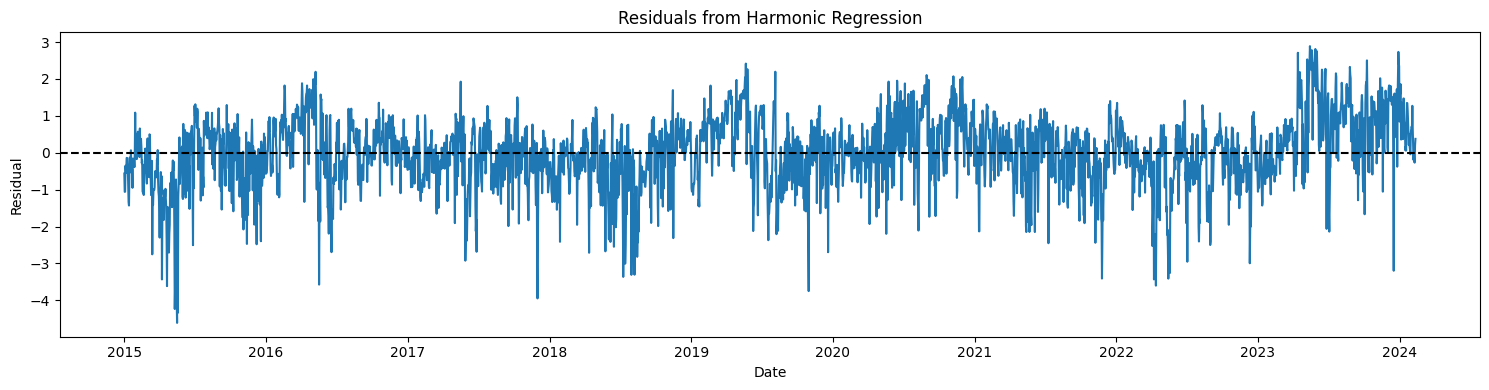

In [76]:
# =====================================================
# Residual Time Series
# =====================================================

plt.figure(figsize=(15,4))

plt.plot(fourier_residuals)

plt.axhline(0, color="black", linestyle="--")

plt.title("Residuals from Harmonic Regression")

plt.xlabel("Date")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

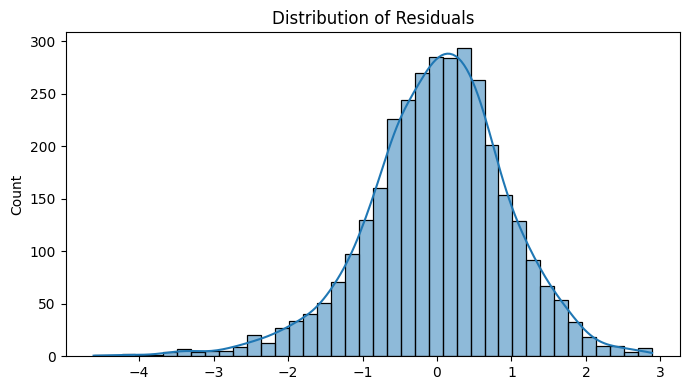

In [77]:
# =====================================================
# Residual Distribution
# =====================================================

plt.figure(figsize=(7,4))

sns.histplot(
    fourier_residuals,
    bins=40,
    kde=True
)

plt.title("Distribution of Residuals")

plt.tight_layout()
plt.show()

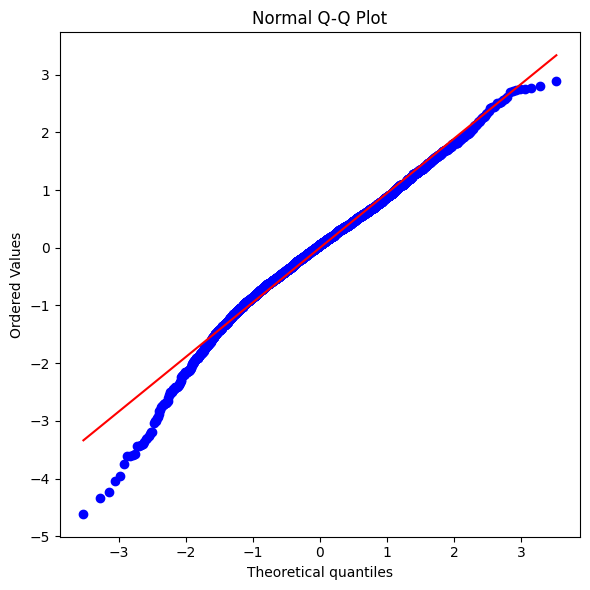

In [78]:
# =====================================================
# QQ Plot
# =====================================================

from scipy.stats import probplot

plt.figure(figsize=(6,6))

probplot(
    fourier_residuals,
    dist="norm",
    plot=plt
)

plt.title("Normal Q-Q Plot")

plt.tight_layout()

plt.show()

<Figure size 1000x400 with 0 Axes>

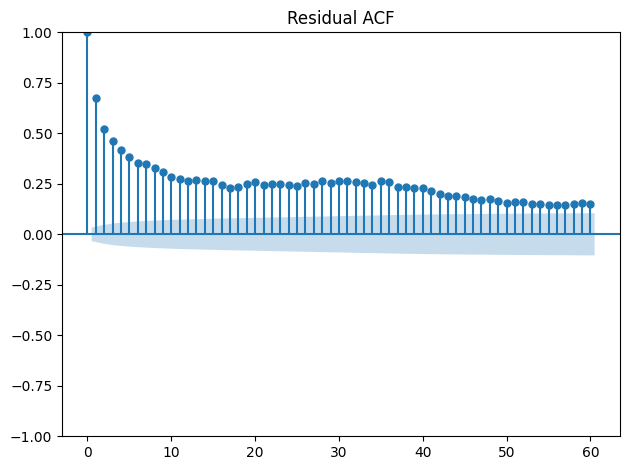

In [79]:
# =====================================================
# Residual ACF
# =====================================================

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))

plot_acf(
    fourier_residuals,
    lags=60
)

plt.title("Residual ACF")

plt.tight_layout()

plt.show()

In [80]:
# =====================================================
# Ljung-Box Test
# =====================================================

from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(
    fourier_residuals,
    lags=[10,20,30],
    return_df=True
)

lb

,lb_stat,lb_pvalue
10,5966.952066,0.0
20,8144.976455,0.0
30,10268.589007,0.0


In [81]:
# =====================================================
# Durbin-Watson Statistic
# =====================================================

from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(fourier_residuals)

print(f"Durbin-Watson statistic: {dw:.3f}")

Durbin-Watson statistic: 0.645


### Residual Analysis

Although Fourier Regression substantially improved forecasting accuracy, the residual diagnostics indicate that the model has not fully captured the temporal dependence in the series. The Durbin–Watson statistic (0.645) suggests strong positive autocorrelation, while the Ljung–Box test rejects the null hypothesis of independent residuals at all examined lags (p < 0.001). These results indicate that the remaining residuals are not white noise and motivate the use of a Dynamic Harmonic Regression model, where the deterministic seasonal component is retained and the residual dependence is modeled using an ARIMA process.

## ARIMA Model

ARIMA models the temporal dependence in the series using autoregressive and moving average components after differencing for stationarity. Unlike the Fourier Regression model, ARIMA does not explicitly model annual seasonality. This model serves as a benchmark to evaluate how well a purely stochastic approach can forecast the temperature series.

In [82]:
# =====================================================
# ARIMA Order Selection
# =====================================================

from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

candidate_models = []

for p in range(4):
    for d in range(2):
        for q in range(4):

            try:

                model = ARIMA(
                    train_sub["avg_temp"],
                    order=(p,d,q)
                )

                fit = model.fit()

                candidate_models.append({
                    "order":(p,d,q),
                    "AIC":fit.aic
                })

            except:
                continue

candidate_models = (
    pd.DataFrame(candidate_models)
    .sort_values("AIC")
    .reset_index(drop=True)
)

candidate_models.head(10)

,order,AIC
0,"(2, 0, 3)",6166.622341
1,"(3, 0, 3)",6168.045478
2,"(3, 0, 2)",6169.016424
3,"(2, 0, 1)",6170.562906
4,"(2, 0, 2)",6172.408905
5,"(3, 0, 1)",6172.456485
6,"(3, 1, 1)",6177.577741
7,"(1, 1, 3)",6177.996635
8,"(2, 1, 3)",6179.295418
9,"(3, 1, 2)",6179.563963


In [83]:
# =====================================================
# Validation Forecast Comparison
# =====================================================

validation_results = []

top_orders = candidate_models.head(5)["order"]

for order in top_orders:

    model = ARIMA(
        train_sub["avg_temp"],
        order=order
    )

    fit = model.fit()

    pred = fit.forecast(steps=len(val))

    metrics = evaluate_forecast(
        train_sub["avg_temp"],
        val["avg_temp"],
        pred
    )

    validation_results.append({
        "Order":order,
        **metrics
    })

validation_results = (
    pd.DataFrame(validation_results)
    .sort_values("MASE")
    .reset_index(drop=True)
)

validation_results

,Order,MAE,RMSE,sMAPE,MASE
0,"(3, 0, 2)",1.211465,1.538300,4.163983,1.194461
1,"(2, 0, 2)",1.212114,1.538999,4.166277,1.195100
2,"(2, 0, 1)",1.213396,1.540460,4.170809,1.196364
3,"(3, 0, 3)",1.216640,1.544633,4.182284,1.199563
4,"(2, 0, 3)",1.219084,1.546933,4.190922,1.201973


In [84]:
best_order = validation_results.iloc[0]["Order"]

print("Selected ARIMA Order:", best_order)

Selected ARIMA Order: (3, 0, 2)


In [85]:
# =====================================================
# Final ARIMA Model
# =====================================================

arima_model = ARIMA(
    train["avg_temp"],
    order=best_order
)

arima_fit = arima_model.fit()

In [86]:
# =====================================================
# Forecast Test Set
# =====================================================

arima_forecast = arima_fit.forecast(
    steps=len(test)
)

arima_forecast = pd.Series(
    arima_forecast,
    index=test.index
)

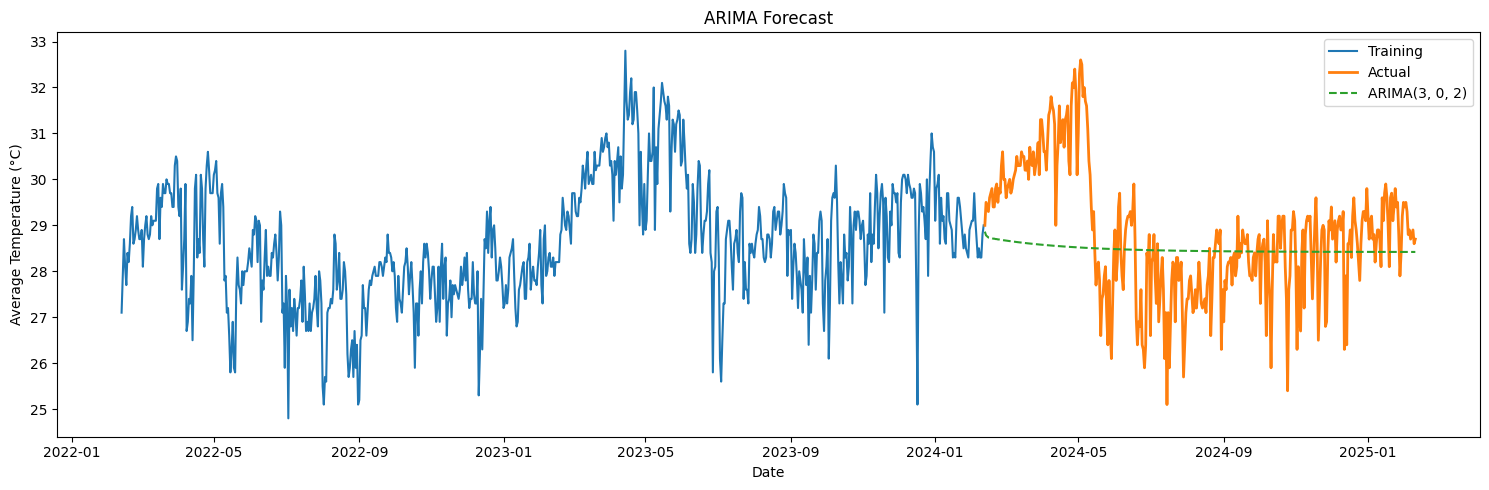

In [87]:
# =====================================================
# ARIMA Forecast
# =====================================================

plt.figure(figsize=(15,5))

plt.plot(
    train.index[-730:],
    train["avg_temp"][-730:],
    label="Training"
)

plt.plot(
    test.index,
    test["avg_temp"],
    label="Actual",
    linewidth=2
)

plt.plot(
    test.index,
    arima_forecast,
    "--",
    label=f"ARIMA{best_order}"
)

plt.title("ARIMA Forecast")

plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")

plt.legend()

plt.tight_layout()

plt.show()

In [88]:
# =====================================================
# Evaluate ARIMA
# =====================================================

arima_results = evaluate_forecast(
    train["avg_temp"],
    test["avg_temp"],
    arima_forecast
)

results.loc[f"ARIMA{best_order}"] = pd.Series(arima_results)

results.round(3)

,MAE,RMSE,sMAPE,MASE
Seasonal Naïve,1.143,1.497,3.958,1.070
Seasonal Moving Average,1.220,1.445,4.242,1.142
Fourier Regression,0.821,1.001,2.859,0.768
"ARIMA(3, 0, 2)",1.071,1.381,3.715,1.003


### Results

The ARIMA model achieved a modest improvement over the Seasonal Naïve benchmark, indicating that the series contains short-term temporal dependence. However, it did not outperform the Fourier Regression model, which achieved substantially lower forecast errors across all evaluation metrics. This suggests that deterministic annual seasonality contributes more to forecast accuracy than stochastic autoregressive and moving average dynamics alone.

# Conclusions

The objective of this study was to compare classical statistical forecasting methods for daily average temperature prediction at the Thiruvananthapuram weather station.

Key observations are:

- The series exhibits a strong annual seasonal pattern with relatively stable variance.
- Seasonal benchmark models provide reasonable forecasts but fail to capture the smooth annual cycle accurately.
- Fourier Regression substantially improves forecast accuracy by explicitly modelling deterministic annual seasonality.
- Residual diagnostics indicate that although Fourier Regression captures most of the seasonal structure, some short-term autocorrelation remains.
- A non-seasonal ARIMA model captures temporal dependence but performs worse than Fourier Regression, indicating that deterministic seasonality contributes more to forecast accuracy than stochastic dependence.

Overall, Fourier Regression achieved the best forecasting performance and is selected as the final model for this dataset.